# **Capstone Project**
Submitted by - **Mohammad Daarim Javed**

Submitted to - **Mustafa Hasan Sir**

Roll No - **J240212046**

Branch - **CSEDS**

---



###Task 1: Fetch Stock Data

In [1]:
# Importing the required libraries
import pandas as pd
import numpy as np
import yfinance as yf


In [2]:
# Defining assets
assets = [
    "^BSESN",
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS"
]

In [3]:
# Downloading all the stocks using for loop

stock_data = {}

for ticker in assets:

    df = yf.download(ticker, period="5y")

    # Flatten MultiIndex columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Convert index into Date column
    df = df.reset_index()

    # Save clean CSV
    df.to_csv(f"data_{ticker}.csv", index=False)

    # Store the DataFrame in the stock_data dictionary
    stock_data[ticker] = df

print("All files saved successfully!")

/tmp/ipykernel_3431/2726455205.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3431/2726455205.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3431/2726455205.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3431/2726455205.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3431/2726455205.py:7: FutureWarning: YF.download() has changed argument auto_adjust defau

All files saved successfully!


In [4]:
# Verification
print(stock_data.keys())

dict_keys(['^BSESN', 'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS'])


In [5]:
# Checking one stock if everything is fine or not
stock_data["RELIANCE.NS"].head()

Price,Date,Close,High,Low,Open,Volume
0,2021-08-06,946.168152,972.392083,941.503067,964.692456,16620987
1,2021-08-09,940.778442,946.507893,935.954862,942.522196,7494143
2,2021-08-10,945.715271,957.015617,939.238565,942.975138,11919198
3,2021-08-11,958.963135,960.185997,943.609225,949.746236,9184963
4,2021-08-12,955.883240,962.994048,953.392172,962.405229,8137612


###Task 2: Fetch News Data

In [6]:
# Importing the required library

import requests


In [9]:
# Storing API Key

from google.colab import userdata
NEWS_API_KEY = userdata.get('NewsAPI')

In [10]:
company_names = {
    "^BSESN": "BSE Sensex",
    "RELIANCE.NS": "Reliance Industries",
    "TCS.NS": "Tata Consultancy Services",
    "INFY.NS": "Infosys",
    "HDFCBANK.NS": "HDFC Bank"
}

In [11]:
# Defining the Fetch Function

def fetch_news(company):

    url = "https://newsapi.org/v2/everything"

    params = {
        "q": f'"{company}"',
        "language": "en",
        "sortBy": "publishedAt",
        "pageSize": 20,
        "searchIn": "title,description",
        "apiKey": NEWS_API_KEY
    }

    response = requests.get(url, params=params)

    return response.json()

In [12]:
# Testing the Function

news = fetch_news("Reliance Industries")

print(news["status"])

ok


In [13]:
# Fetching News for All 5 Companies

all_news = {}

for ticker, company in company_names.items():

    print(f"Fetching news for {company}...")

    news = fetch_news(company)

    all_news[ticker] = news

print("News fetched successfully!")

Fetching news for BSE Sensex...
Fetching news for Reliance Industries...
Fetching news for Tata Consultancy Services...
Fetching news for Infosys...
Fetching news for HDFC Bank...
News fetched successfully!


In [14]:
# Checking Whether the News Was Downloaded

print(all_news.keys())

dict_keys(['^BSESN', 'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS'])


In [15]:
# Saving the News as CSV Files

for ticker, news_data in all_news.items():

    articles = news_data.get("articles", [])

    if len(articles) == 0:
        print(f"No news found for {ticker}")
        continue

    news_df = pd.DataFrame(articles)

    filename = f"news_{ticker}.csv"

    news_df.to_csv(filename, index=False)

    print(f"{filename} saved successfully.")

news_^BSESN.csv saved successfully.
news_RELIANCE.NS.csv saved successfully.
news_TCS.NS.csv saved successfully.
news_INFY.NS.csv saved successfully.
news_HDFCBANK.NS.csv saved successfully.


In [16]:
# Verifying One CSV

reliance_news = pd.read_csv("news_RELIANCE.NS.csv")

reliance_news.head(3)

,source,author,title,description,url,urlToImage,publishedAt,content
0,"{'id': None, 'name': 'BusinessLine'}",Avinash Nair & Sourashis Banerjee,Five large listed companies account for 45% of...,"HDFC Bank, Reliance Industries, TCS, ICICI Ban...",https://www.thehindubusinessline.com/companies...,https://bl-i.thgim.com/public/incoming/c5dzn4/...,2026-08-04T15:46:32Z,A handful of corporate giants continued to dri...
1,"{'id': None, 'name': 'Economictimes.com'}",THE ECONOMIC TIMES,"Reliance Industries, ICICI Bank among 11 stock...",Nifty companies have reported stronger-than-ex...,https://m.economictimes.com/markets/stocks/new...,"https://img.etimg.com/thumb/msid-132844690,wid...",2026-08-04T02:35:35Z,"Aug 04, 2026, 08:10:12 AM IST\r\nNifty compani..."
2,"{'id': 'the-times-of-india', 'name': 'The Time...",Sanjeev Choudhary,Fuel exports hit 1-year high in July on strong...,India's fuel exports hit a one-year peak in Ju...,https://economictimes.indiatimes.com/news/econ...,"https://img.etimg.com/thumb/msid-132843774,wid...",2026-08-04T01:08:12Z,New Delhi: The nations fuel exports surged to ...


###Task 3: Clean the Data

In [17]:
# Cleaning the Stock Data

for ticker, df in stock_data.items():

    print(f"\nCleaning {ticker}...")

    # Flattening MultiIndex columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Converting index to datetime
    df.index = pd.to_datetime(df.index)

    # Checking missing values
    print("Missing Values:")
    print(df.isnull().sum())

    # Dropping missing values
    df.dropna(inplace=True)

    # Saving cleaned dataframe back
    stock_data[ticker] = df

print("\nStock data cleaned successfully!")


Cleaning ^BSESN...
Missing Values:
Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Cleaning RELIANCE.NS...
Missing Values:
Price
Date      0
Close     1
High      1
Low       1
Open      1
Volume    0
dtype: int64

Cleaning TCS.NS...
Missing Values:
Price
Date      0
Close     1
High      1
Low       1
Open      1
Volume    0
dtype: int64

Cleaning INFY.NS...
Missing Values:
Price
Date      0
Close     1
High      1
Low       1
Open      1
Volume    0
dtype: int64

Cleaning HDFCBANK.NS...
Missing Values:
Price
Date      0
Close     1
High      1
Low       1
Open      1
Volume    0
dtype: int64

Stock data cleaned successfully!


In [18]:
# Verifying One Stock

stock_data["RELIANCE.NS"].head()

Price,Date,Close,High,Low,Open,Volume
1970-01-01 00:00:00.000000000,2021-08-06,946.168152,972.392083,941.503067,964.692456,16620987
1970-01-01 00:00:00.000000001,2021-08-09,940.778442,946.507893,935.954862,942.522196,7494143
1970-01-01 00:00:00.000000002,2021-08-10,945.715271,957.015617,939.238565,942.975138,11919198
1970-01-01 00:00:00.000000003,2021-08-11,958.963135,960.185997,943.609225,949.746236,9184963
1970-01-01 00:00:00.000000004,2021-08-12,955.883240,962.994048,953.392172,962.405229,8137612


In [19]:
# Reading the News CSV Files
# We need to clean the news data as well

news_data = {}

for ticker in assets:

    filename = f"news_{ticker}.csv"

    df = pd.read_csv(filename)

    news_data[ticker] = df

print("News files loaded successfully!")

News files loaded successfully!


In [20]:
# Cleaning the news data

for ticker, df in news_data.items():

    print(f"\nCleaning news for {ticker}...")

    # Missing values
    print(df.isnull().sum())

    # Convert published date
    if "publishedAt" in df.columns:
        df["publishedAt"] = pd.to_datetime(df["publishedAt"])

    # Remove duplicate articles
    df.drop_duplicates(inplace=True)

    # Fill missing text columns
    text_columns = ["title", "description", "content"]

    for col in text_columns:
        if col in df.columns:
            df[col] = df[col].fillna("")

    news_data[ticker] = df

print("\nNews data cleaned successfully!")


Cleaning news for ^BSESN...
source         0
author         0
title          0
description    0
url            0
urlToImage     0
publishedAt    0
content        0
dtype: int64

Cleaning news for RELIANCE.NS...
source         0
author         0
title          0
description    0
url            0
urlToImage     0
publishedAt    0
content        0
dtype: int64

Cleaning news for TCS.NS...
source         0
author         4
title          0
description    1
url            0
urlToImage     3
publishedAt    0
content        0
dtype: int64

Cleaning news for INFY.NS...
source         0
author         3
title          0
description    0
url            0
urlToImage     0
publishedAt    0
content        0
dtype: int64

Cleaning news for HDFCBANK.NS...
source         0
author         0
title          0
description    0
url            0
urlToImage     1
publishedAt    0
content        0
dtype: int64

News data cleaned successfully!


In [21]:
# Verification

news_data["RELIANCE.NS"].head(3)

,source,author,title,description,url,urlToImage,publishedAt,content
0,"{'id': None, 'name': 'BusinessLine'}",Avinash Nair & Sourashis Banerjee,Five large listed companies account for 45% of...,"HDFC Bank, Reliance Industries, TCS, ICICI Ban...",https://www.thehindubusinessline.com/companies...,https://bl-i.thgim.com/public/incoming/c5dzn4/...,2026-08-04 15:46:32+00:00,A handful of corporate giants continued to dri...
1,"{'id': None, 'name': 'Economictimes.com'}",THE ECONOMIC TIMES,"Reliance Industries, ICICI Bank among 11 stock...",Nifty companies have reported stronger-than-ex...,https://m.economictimes.com/markets/stocks/new...,"https://img.etimg.com/thumb/msid-132844690,wid...",2026-08-04 02:35:35+00:00,"Aug 04, 2026, 08:10:12 AM IST\r\nNifty compani..."
2,"{'id': 'the-times-of-india', 'name': 'The Time...",Sanjeev Choudhary,Fuel exports hit 1-year high in July on strong...,India's fuel exports hit a one-year peak in Ju...,https://economictimes.indiatimes.com/news/econ...,"https://img.etimg.com/thumb/msid-132843774,wid...",2026-08-04 01:08:12+00:00,New Delhi: The nations fuel exports surged to ...


### Task 4: Exploratory Data Analysis (EDA)

In [22]:
# Importing the required libraries
import plotly.express as px
import plotly.graph_objects as go

In [23]:
# Price Trend

for ticker, df in stock_data.items():

    fig = px.line(
        df,
        x=df.index,
        y="Close",
        title=f"{ticker} Price Trend"
    )

    fig.show()

In [24]:
# Daily Returns

for ticker, df in stock_data.items():

    df["daily_return"] = df["Close"].pct_change() * 100

    fig = px.histogram(
        df,
        x="daily_return",
        nbins=50,
        title=f"{ticker} Daily Return Distribution"
    )

    fig.show()

In [25]:
# Volume Trend

for ticker, df in stock_data.items():

    fig = px.line(
        df,
        x=df.index,
        y="Volume",
        title=f"{ticker} Volume Trend"
    )

    fig.show()

In [26]:
# Correlation Heatmap

for ticker, df in stock_data.items():

    corr = df.corr(numeric_only=True)

    fig = px.imshow(
        corr,
        text_auto=True,
        title=f"{ticker} Correlation Heatmap"
    )

    fig.show()

In [27]:
# Summary statistics table

for ticker, df in stock_data.items():

    print(f"\n========== {ticker} ==========\n")

    display(df.describe())


========== ^BSESN ==========



Price,Date,Close,High,Low,Open,Volume,daily_return
count,1232,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1231.000000
mean,2024-02-03 06:18:42.077922048,69918.973195,70263.521865,69566.719127,69942.989949,12312.418831,0.033900
min,2021-08-06 00:00:00,51360.421875,51652.828125,50921.218750,51181.988281,0.000000,-5.740558
25%,2022-11-02 18:00:00,60054.193359,60362.546875,59766.062500,60082.321289,7175.000000,-0.430573
50%,2024-02-03 12:00:00,72019.097656,72394.300781,71588.515625,72026.785156,9500.000000,0.047393
75%,2025-05-08 06:00:00,79710.458984,80103.150391,79227.376953,79746.613281,13800.000000,0.528706
max,2026-08-05 00:00:00,85836.117188,86159.023438,85577.820312,86065.921875,452000.000000,3.948614
std,NaN,10073.964339,10100.921208,10062.089072,10078.330436,15441.088486,0.875636



========== RELIANCE.NS ==========



Price,Date,Close,High,Low,Open,Volume,daily_return
count,1238,1238.000000,1238.000000,1238.000000,1238.000000,1.238000e+03,1237.000000
mean,2024-02-06 03:41:00.096930560,1267.477331,1279.361632,1256.379028,1267.987502,1.333506e+07,0.034319
min,2021-08-06 00:00:00,940.778442,946.507893,935.954862,942.522196,0.000000e+00,-7.485140
25%,2022-11-04 18:00:00,1145.208344,1154.033600,1135.810630,1146.226576,8.879726e+06,-0.795818
50%,2024-02-06 12:00:00,1244.579224,1258.331029,1233.234622,1246.037197,1.179931e+07,0.036052
75%,2025-05-12 18:00:00,1402.149017,1414.478399,1389.121474,1403.063149,1.611188e+07,0.781697
max,2026-08-05 00:00:00,1584.971802,1604.382010,1570.936597,1585.668486,8.199715e+07,7.019202
std,NaN,148.263996,149.030911,147.770399,148.420850,6.822141e+06,1.407198



========== TCS.NS ==========



Price,Date,Close,High,Low,Open,Volume,daily_return
count,1238,1238.000000,1238.000000,1238.000000,1238.000000,1.238000e+03,1237.000000
mean,2024-02-06 03:41:00.096930560,3163.664401,3193.062565,3135.957293,3165.226255,2.599668e+06,-0.004202
min,2021-08-06 00:00:00,1971.788818,2040.810403,1966.020519,1997.050382,0.000000e+00,-8.386122
25%,2022-11-04 18:00:00,2915.230408,2938.172388,2890.890861,2915.653319,1.637294e+06,-0.729337
50%,2024-02-06 12:00:00,3107.383545,3134.131417,3081.744569,3112.824709,2.159260e+06,-0.020334
75%,2025-05-12 18:00:00,3394.979614,3434.044804,3357.954231,3407.838637,3.036382e+06,0.721939
max,2026-08-05 00:00:00,4230.710449,4266.479289,4191.920798,4251.380667,1.633158e+07,6.632770
std,NaN,448.662209,452.415370,445.367738,448.322406,1.640691e+06,1.411339



========== INFY.NS ==========



Price,Date,Close,High,Low,Open,Volume,daily_return
count,1238,1238.000000,1238.000000,1238.000000,1238.000000,1.238000e+03,1237.000000
mean,2024-02-06 03:41:00.096930560,1437.240887,1451.164980,1423.620512,1437.815169,7.610561e+06,-0.003146
min,2021-08-06 00:00:00,985.299988,1014.000000,982.400024,1006.000000,0.000000e+00,-9.422690
25%,2022-11-04 18:00:00,1309.471649,1322.924105,1299.290419,1308.206286,4.646283e+06,-0.915764
50%,2024-02-06 12:00:00,1425.476562,1437.893606,1412.084677,1426.192171,6.329701e+06,-0.003302
75%,2025-05-12 18:00:00,1546.493439,1558.384904,1527.906126,1543.519237,8.692056e+06,0.910552
max,2026-08-05 00:00:00,1901.082886,1907.500003,1880.072854,1897.042542,6.908543e+07,7.934017
std,NaN,188.216859,189.802055,186.234896,188.069631,5.343081e+06,1.623507



========== HDFCBANK.NS ==========



Price,Date,Close,High,Low,Open,Volume,daily_return
count,1238,1238.000000,1238.000000,1238.000000,1238.000000,1.238000e+03,1237.000000
mean,2024-02-06 03:41:00.096930560,788.043725,794.537485,781.607774,787.798022,2.740941e+07,0.012831
min,2021-08-06 00:00:00,606.489319,613.636584,601.897839,603.507203,0.000000e+00,-8.435817
25%,2022-11-04 18:00:00,716.264603,723.478828,710.954606,717.016416,1.394278e+07,-0.665047
50%,2024-02-06 12:00:00,773.592102,780.922374,766.856518,773.205196,2.226431e+07,0.015356
75%,2025-05-12 18:00:00,831.794861,841.157510,825.835678,832.298016,3.423429e+07,0.692064
max,2026-08-05 00:00:00,996.419800,1003.896124,992.091365,1000.944932,4.453421e+08,10.013273
std,NaN,95.440333,95.718906,95.452951,95.636536,2.519413e+07,1.318950


### Task 5: Feature Engineering

In [28]:
# Creating All the Features

for ticker, df in stock_data.items():

    print(f"Creating features for {ticker}...")

    # ----------------------------
    # Price Features
    # ----------------------------

    df["daily_return"] = df["Close"].pct_change() * 100

    df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

    df["ma_30"] = df["Close"].rolling(30).mean()

    df["price_ma_ratio"] = df["Close"] / df["ma_30"]

    df["high_low_ratio"] = df["High"] / df["Low"]

    # ----------------------------
    # Trend Features
    # ----------------------------

    df["ma_7"] = df["Close"].rolling(7).mean()

    df["ma_14"] = df["Close"].rolling(14).mean()

    df["ma_crossover"] = (df["ma_7"] > df["ma_30"]).astype(int)

    # ----------------------------
    # Volatility Features
    # ----------------------------

    df["volatility_7"] = df["daily_return"].rolling(7).std()

    df["volatility_14"] = df["daily_return"].rolling(14).std()

    # ----------------------------
    # Time Features
    # ----------------------------

    df["day_of_week"] = df.index.dayofweek

    df["month"] = df.index.month

    df["quarter"] = df.index.quarter

    df["is_monday"] = (df.index.dayofweek == 0).astype(int)

    df["is_friday"] = (df.index.dayofweek == 4).astype(int)

    # ----------------------------
    # Volume Features
    # ----------------------------

    df["volume_ma_7"] = df["Volume"].rolling(7).mean()

    df["volume_ratio"] = df["Volume"] / df["volume_ma_7"]

    # ----------------------------
    # Target Variable
    # ----------------------------

    df["target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

    # Removing rows created by rolling windows
    df.dropna(inplace=True)

    stock_data[ticker] = df

print("Feature Engineering Completed!")

Creating features for ^BSESN...
Creating features for RELIANCE.NS...
Creating features for TCS.NS...
Creating features for INFY.NS...
Creating features for HDFCBANK.NS...
Feature Engineering Completed!


In [29]:
# Verifying the Features

stock_data["RELIANCE.NS"].columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'daily_return',
       'log_return', 'ma_30', 'price_ma_ratio', 'high_low_ratio', 'ma_7',
       'ma_14', 'ma_crossover', 'volatility_7', 'volatility_14', 'day_of_week',
       'month', 'quarter', 'is_monday', 'is_friday', 'volume_ma_7',
       'volume_ratio', 'target'],
      dtype='object', name='Price')

In [30]:
stock_data["RELIANCE.NS"].head()

Price,Date,Close,High,Low,Open,Volume,daily_return,log_return,ma_30,price_ma_ratio,...,volatility_7,volatility_14,day_of_week,month,quarter,is_monday,is_friday,volume_ma_7,volume_ratio,target
1970-01-01 00:00:00.000000029,2021-09-20,1084.444092,1095.314055,1073.415513,1074.366608,11779819,0.158980,0.001589,1023.988538,1.059039,...,1.398382,1.558265,3,1,1,0,0,1.476638e+07,0.797746,1
1970-01-01 00:00:00.000000030,2021-09-21,1089.131714,1094.521411,1079.756260,1089.267567,9915736,0.432260,0.004313,1028.753990,1.058690,...,1.418998,1.535375,3,1,1,0,0,1.490245e+07,0.665376,1
1970-01-01 00:00:00.000000031,2021-09-22,1100.816895,1106.025333,1086.210242,1090.626201,10995912,1.072890,0.010672,1034.088605,1.064529,...,1.115708,1.543807,3,1,1,0,0,1.414313e+07,0.777474,1
1970-01-01 00:00:00.000000032,2021-09-23,1127.720337,1130.936017,1107.610774,1108.471300,15748397,2.443953,0.024146,1040.155440,1.084184,...,1.331721,1.620390,3,1,1,0,0,1.512028e+07,1.041541,0
1970-01-01 00:00:00.000000033,2021-09-24,1124.459229,1134.763134,1119.613066,1133.902609,15192163,-0.289177,-0.002896,1045.671977,1.075346,...,1.384569,1.279112,3,1,1,0,0,1.599472e+07,0.949824,1


###Task 6: Build Model for a Single Asset

In [31]:
# Importing Required Libraries

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [32]:
# Defining the Feature Columns
# Instead of typing the column names repeatedly, we will create a list once

feature_columns = [
    "daily_return",
    "log_return",
    "ma_7",
    "ma_14",
    "ma_30",
    "price_ma_ratio",
    "high_low_ratio",
    "ma_crossover",
    "volatility_7",
    "volatility_14",
    "day_of_week",
    "month",
    "quarter",
    "is_monday",
    "is_friday",
    "volume_ma_7",
    "volume_ratio"
]


In [33]:
# Writing the process_asset() Function

def process_asset(ticker):

    # Getting the dataframe
    df = stock_data[ticker].copy()

    # Features and Target
    X = df[feature_columns]
    y = df["target"]

    # Time-based Train-Test Split (80%-20%)
    split_index = int(len(df) * 0.8)

    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]

    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    # Pipeline
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ])

    # Training
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)

    y_proba = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    }

    return {
        "model": pipeline,
        "metrics": metrics,
        "predictions": y_pred,
        "probabilities": y_proba,
        "X_test": X_test,
        "y_test": y_test
    }

In [34]:
# Testing the Function

reliance_result = process_asset("RELIANCE.NS")

In [35]:
# Viewing the Metrics

reliance_result["metrics"]

{'Accuracy': 0.5537190082644629,
 'Precision': 0.5365853658536586,
 'Recall': 0.5641025641025641,
 'F1 Score': 0.55,
 'ROC AUC': np.float64(0.5307350427350428)}

###Task 7: Run Model for All Assets

In [36]:
# Processing All Assets

results = {}

for ticker in assets:

    print(f"Processing {ticker}...")

    results[ticker] = process_asset(ticker)

print("\nAll assets processed successfully!")

Processing ^BSESN...
Processing RELIANCE.NS...
Processing TCS.NS...
Processing INFY.NS...
Processing HDFCBANK.NS...

All assets processed successfully!


In [37]:
# Checking the Dictionary

results.keys()

dict_keys(['^BSESN', 'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS'])

In [38]:
# Viewing Result

results["RELIANCE.NS"]


{'model': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', RandomForestClassifier(random_state=42))]),
 'metrics': {'Accuracy': 0.5537190082644629,
  'Precision': 0.5365853658536586,
  'Recall': 0.5641025641025641,
  'F1 Score': 0.55,
  'ROC AUC': np.float64(0.5307350427350428)},
 'predictions': array([1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
        1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1,
        1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
        1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
        1, 1, 

In [39]:
# Displaying Metrics for All Assets

comparison_df = pd.DataFrame({
    ticker: results[ticker]["metrics"]
    for ticker in assets
}).T

comparison_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC
^BSESN,0.510373,0.533333,0.387097,0.448598,0.537669
RELIANCE.NS,0.553719,0.536585,0.564103,0.550000,0.530735
TCS.NS,0.483471,0.462963,0.663717,0.545455,0.486108
INFY.NS,0.425620,0.405714,0.669811,0.505338,0.447870
HDFCBANK.NS,0.454545,0.392157,0.606061,0.476190,0.507417


### Task 8: Calculate Business Metrics

In [40]:
# Creating a Business Metrics Table

business_metrics = comparison_df.copy()

business_metrics = business_metrics.round(4)

business_metrics

,Accuracy,Precision,Recall,F1 Score,ROC AUC
^BSESN,0.5104,0.5333,0.3871,0.4486,0.5377
RELIANCE.NS,0.5537,0.5366,0.5641,0.5500,0.5307
TCS.NS,0.4835,0.4630,0.6637,0.5455,0.4861
INFY.NS,0.4256,0.4057,0.6698,0.5053,0.4479
HDFCBANK.NS,0.4545,0.3922,0.6061,0.4762,0.5074


In [41]:
# Finding the Best Asset for Each Metric

for metric in business_metrics.columns:

    best_asset = business_metrics[metric].idxmax()

    best_value = business_metrics[metric].max()

    print(f"{metric}:")
    print(f"   Best Asset : {best_asset}")
    print(f"   Value      : {best_value:.4f}\n")

Accuracy:
   Best Asset : RELIANCE.NS
   Value      : 0.5537

Precision:
   Best Asset : RELIANCE.NS
   Value      : 0.5366

Recall:
   Best Asset : INFY.NS
   Value      : 0.6698

F1 Score:
   Best Asset : RELIANCE.NS
   Value      : 0.5500

ROC AUC:
   Best Asset : ^BSESN
   Value      : 0.5377



In [42]:
# Creating a Bar Chart

import plotly.express as px

fig = px.bar(
    business_metrics,
    barmode="group",
    title="Business Metrics Comparison Across Assets",
    labels={
        "index": "Stock",
        "value": "Score",
        "variable": "Metric"
    }
)

fig.show()

In [43]:
# Ranking the Stocks by Accuracy

accuracy_ranking = business_metrics.sort_values(
    by="Accuracy",
    ascending=False
)

accuracy_ranking

,Accuracy,Precision,Recall,F1 Score,ROC AUC
RELIANCE.NS,0.5537,0.5366,0.5641,0.5500,0.5307
^BSESN,0.5104,0.5333,0.3871,0.4486,0.5377
TCS.NS,0.4835,0.4630,0.6637,0.5455,0.4861
HDFCBANK.NS,0.4545,0.3922,0.6061,0.4762,0.5074
INFY.NS,0.4256,0.4057,0.6698,0.5053,0.4479


In [44]:
# Printing a Summary

print("Business Metrics Summary\n")

print(f"Highest Accuracy : {business_metrics['Accuracy'].idxmax()}")
print(f"Highest Precision: {business_metrics['Precision'].idxmax()}")
print(f"Highest Recall   : {business_metrics['Recall'].idxmax()}")
print(f"Highest F1 Score : {business_metrics['F1 Score'].idxmax()}")
print(f"Highest ROC AUC  : {business_metrics['ROC AUC'].idxmax()}")

Business Metrics Summary

Highest Accuracy : RELIANCE.NS
Highest Precision: RELIANCE.NS
Highest Recall   : INFY.NS
Highest F1 Score : RELIANCE.NS
Highest ROC AUC  : ^BSESN


###Task 9: Threshold Tuning

In [45]:
# Importing required libraries

import numpy as np
from sklearn.metrics import confusion_matrix

In [46]:
# Defining the Costs

cost_fp = 100
cost_fn = 50

In [47]:
# Creating the Threshold Function

def threshold_tuning(result):

    y_test = result["y_test"]
    y_proba = result["probabilities"]

    thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)

    threshold_results = []

    for threshold in thresholds:

        y_pred = (y_proba >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        total_cost = (fp * cost_fp) + (fn * cost_fn)

        threshold_results.append({
            "Threshold": threshold,
            "False Positives": fp,
            "False Negatives": fn,
            "Business Cost": total_cost
        })

    threshold_df = pd.DataFrame(threshold_results)

    best_row = threshold_df.loc[
        threshold_df["Business Cost"].idxmin()
    ]

    return threshold_df, best_row

In [48]:
# Testing on One Stock

threshold_df, best_row = threshold_tuning(
    results["RELIANCE.NS"]
)

threshold_df

,Threshold,False Positives,False Negatives,Business Cost
0,0.10,125,0,12500
1,0.15,125,0,12500
2,0.20,125,1,12550
3,0.25,124,2,12500
4,0.30,120,4,12200
5,0.35,115,10,12000
6,0.40,103,21,11350
7,0.45,87,38,10600
8,0.50,63,46,8600
9,0.55,46,67,7950


In [49]:
# Best Threshold

best_row

,14
Threshold,0.8
False Positives,0.0
False Negatives,114.0
Business Cost,5700.0


In [50]:
# Cost vs Threshold Graph

fig = px.line(
    threshold_df,
    x="Threshold",
    y="Business Cost",
    markers=True,
    title="Threshold vs Business Cost"
)

fig.show()

In [51]:
# Comparing Default vs Optimal

default_cost = threshold_df.loc[
    np.isclose(threshold_df["Threshold"], 0.50),
    "Business Cost"
].iloc[0]

optimal_cost = best_row["Business Cost"]

print(f"Default Threshold : 0.50")
print(f"Default Cost      : {default_cost}")

print()

print(f"Optimal Threshold : {best_row['Threshold']:.2f}")
print(f"Optimal Cost      : {optimal_cost}")

Default Threshold : 0.50
Default Cost      : 8600

Optimal Threshold : 0.80
Optimal Cost      : 5700.0


###Task 10: Adding SHAP Explainability

In [52]:
# Importing SHAP

import shap

In [53]:
# Choosing One Asset

reliance_model = results["RELIANCE.NS"]["model"]

X_test = results["RELIANCE.NS"]["X_test"]

In [54]:
rf_model = reliance_model.named_steps["model"]

# Scaling the Test Data

scaler = reliance_model.named_steps["scaler"]

X_test_scaled = scaler.transform(X_test)

# Creating the Explainer

explainer = shap.TreeExplainer(rf_model)

# Calculating SHAP Values

shap_values = explainer.shap_values(X_test_scaled)

In [55]:
# Select SHAP values for the positive class
shap_values_class1 = shap_values[:, :, 1]

print(shap_values_class1.shape)

(242, 17)


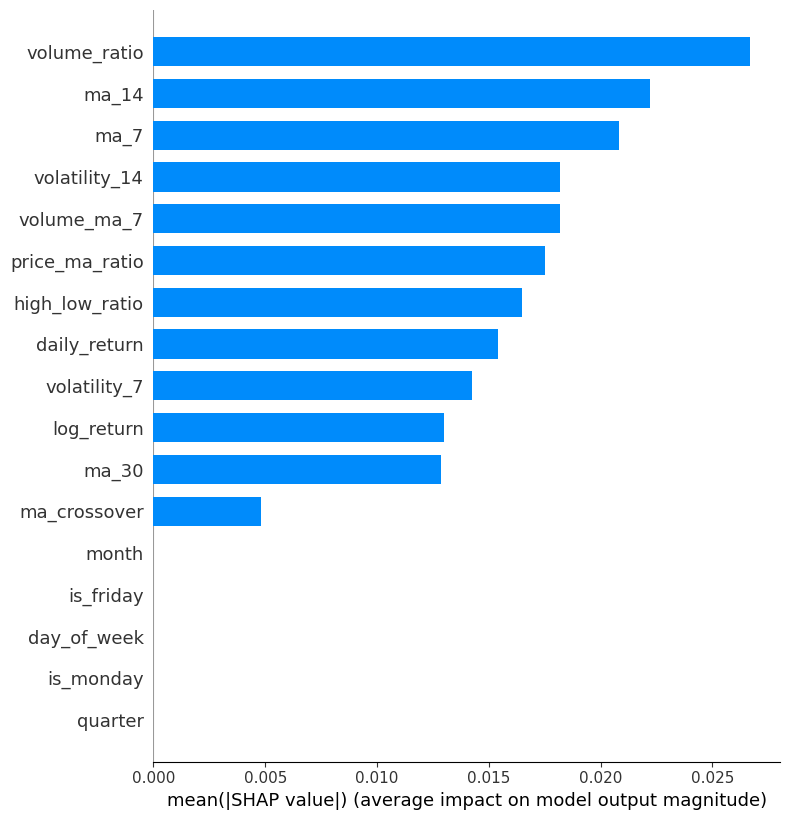

In [56]:
# Global Feature Importance Chart

shap.summary_plot(
    shap_values_class1,
    X_test_scaled,
    feature_names=feature_columns,
    plot_type="bar"
)

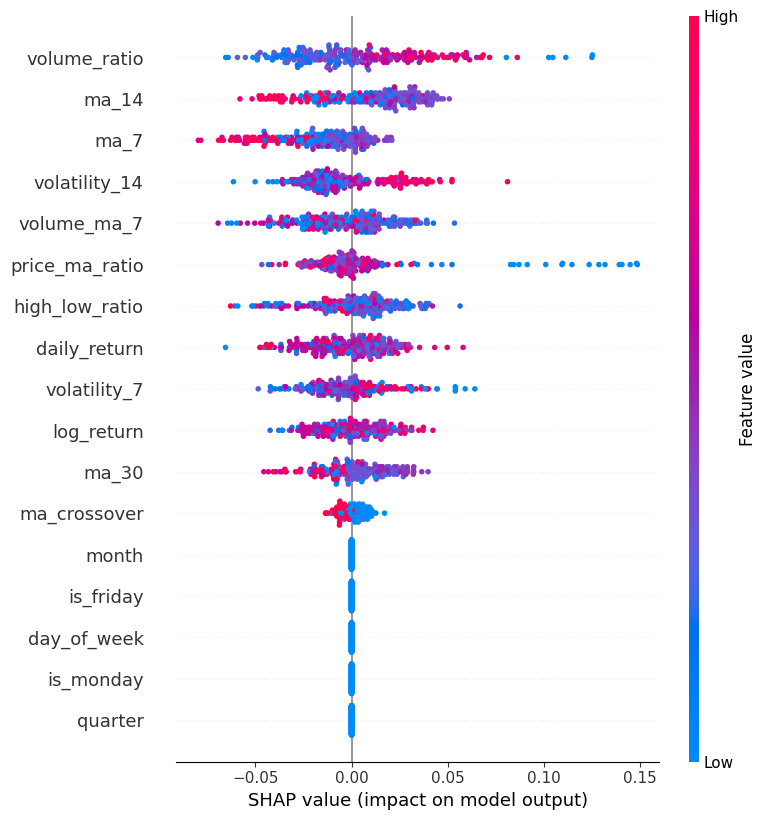

In [57]:
# SHAP Summary Dot Plot

shap.summary_plot(
    shap_values_class1,
    X_test_scaled,
    feature_names=feature_columns
)

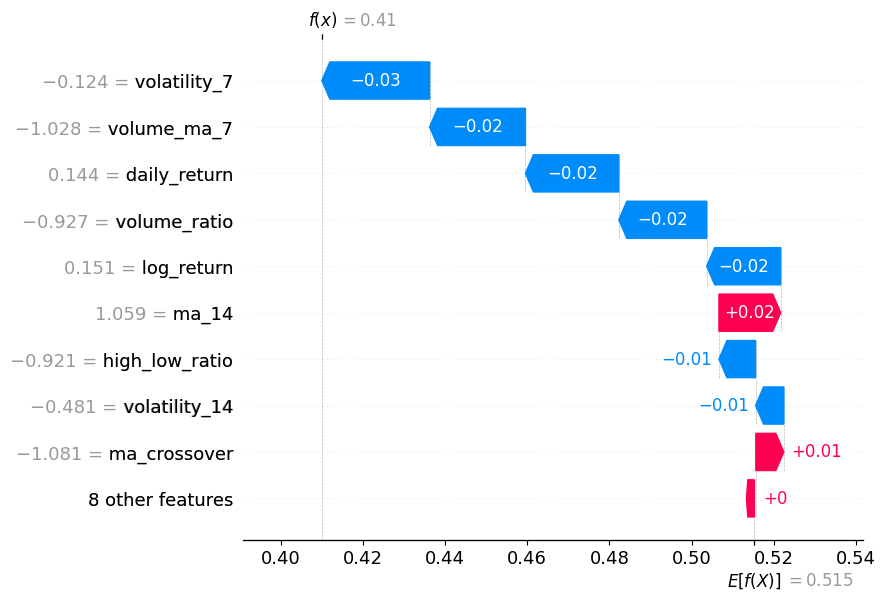

In [58]:
# Waterfall Plot

sample = 5

explanation = shap.Explanation(

    values=shap_values_class1[sample],

    base_values=explainer.expected_value[1],

    data=X_test_scaled[sample],

    feature_names=feature_columns

)

shap.waterfall_plot(explanation)

In [59]:
# Force Plot

shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values_class1[sample],
    X_test_scaled[sample],
    feature_names=feature_columns,
    matplotlib=False
)

###Task 11: Building RAG Pipeline

In [60]:
!pip install chromadb langchain-text-splitters sentence-transformers

# ===============================
# Preparing the News for RAG
# ===============================

# Importing Libraries

from sentence_transformers import SentenceTransformer
import chromadb
from langchain_text_splitters import RecursiveCharacterTextSplitter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-api
    Found 

In [61]:
# Creating a Dictionary for News Text

news_documents = {}

In [62]:
# Converting Each News CSV into One Text Document

for ticker, df in news_data.items():

    print(f"Preparing news for {ticker}...")

    # Replace missing values with empty strings
    df = df.fillna("")

    # Combine important columns into one text
    combined_text = ""

    for _, row in df.iterrows():

        article = f"""
Title: {row['title']}

Description: {row['description']}

Content: {row['content']}
"""

        combined_text += article + "\n\n"

    news_documents[ticker] = combined_text

print("\nNews documents created successfully!")

Preparing news for ^BSESN...
Preparing news for RELIANCE.NS...
Preparing news for TCS.NS...
Preparing news for INFY.NS...
Preparing news for HDFCBANK.NS...

News documents created successfully!


In [63]:
# Verifying One Document

print(news_documents["RELIANCE.NS"][:1000])


Title: Five large listed companies account for 45% of the ₹11,391 crore CSR pool in FY26

Description: HDFC Bank, Reliance Industries, TCS, ICICI Bank and SBI together accounted for over 45% (₹5,143 crore) of the total CSR expenditure

Content: A handful of corporate giants continued to drive Indias CSR landscape in FY26, with the top five spenders accounting for nearly 45 per cent of the 11,391 crore spent by 46 Nifty 50 companies analysed… [+2726 chars]



Title: Reliance Industries, ICICI Bank among 11 stocks with over 3% FY27 earnings upgrades. Own any?

Description: Nifty companies have reported stronger-than-expected first quarter earnings results. Profits for index constituents have risen eleven percent year on year. Reliance Industries and SBI Life Insurance received significant FY27 earnings upgrades. Bajaj Finserv a…

Content: Aug 04, 2026, 08:10:12 AM IST
Nifty companies have delivered a stronger-than-expected start to the first quarter earnings season, with profits of the


In [64]:
# Splitting into Chunks

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)

# Chunk All Documents

news_chunks = {}

for ticker, text in news_documents.items():

    chunks = text_splitter.split_text(text)

    news_chunks[ticker] = chunks

    print(f"{ticker}: {len(chunks)} chunks")

^BSESN: 25 chunks
RELIANCE.NS: 37 chunks
TCS.NS: 33 chunks
INFY.NS: 30 chunks
HDFCBANK.NS: 31 chunks


In [65]:
# Verify

news_chunks["RELIANCE.NS"][0]

'Title: Five large listed companies account for 45% of the ₹11,391 crore CSR pool in FY26\n\nDescription: HDFC Bank, Reliance Industries, TCS, ICICI Bank and SBI together accounted for over 45% (₹5,143 crore) of the total CSR expenditure\n\nContent: A handful of corporate giants continued to drive Indias CSR landscape in FY26, with the top five spenders accounting for nearly 45 per cent of the 11,391 crore spent by 46 Nifty 50 companies analysed… [+2726 chars]'

In [66]:
# ================================
# Create Embeddings
# ================================

# Installing the library
!pip install -q sentence_transformers

from sentence_transformers import SentenceTransformer
import numpy as np

# Creating the Function

def create_embeddings(chunks, model_name="all-MiniLM-L6-v2"):

    """
    Creates embeddings for a list of chunks
    and returns them as a list of lists.
    """

    # Loading Sentence Transformer model
    model = SentenceTransformer(model_name)

    # Creating embeddings
    embeddings = model.encode(
        chunks,
        convert_to_numpy=True
    )

    # Convert NumPy array to list
    embeddings = embeddings.tolist()

    return embeddings



In [67]:
# Creating Embeddings for Every Stock

news_embeddings = {}

for ticker, chunks in news_chunks.items():

    print(f"Creating embeddings for {ticker}...")

    embeddings = create_embeddings(chunks)

    news_embeddings[ticker] = embeddings

print("\nAll embeddings created successfully!")

Creating embeddings for ^BSESN...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Creating embeddings for INFY.NS...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Creating embeddings for HDFCBANK.NS...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


All embeddings created successfully!


In [68]:
# Verification

print("Total Embeddings:", len(news_embeddings["RELIANCE.NS"]))

print()

print(
    "Embedding Dimension:",
    len(news_embeddings["RELIANCE.NS"][0])
)

embeddings_array = np.array(
    news_embeddings["RELIANCE.NS"]
)

print()

print("Embedding Shape:", embeddings_array.shape)

print()

print("First 10 values")

print("-"*50)

print(news_embeddings["RELIANCE.NS"][0][:10])

Total Embeddings: 37

Embedding Dimension: 384

Embedding Shape: (37, 384)

First 10 values
--------------------------------------------------
[0.005868271924555302, -0.026723487302660942, -0.09885648638010025, -0.006765604950487614, 0.05573244392871857, -0.019915228709578514, 0.05777866765856743, 0.03526970371603966, 0.005515302065759897, -0.05142226815223694]


In [69]:
# ======================================
# Building the Vector Search (Retriever)
# ======================================

# Import Cosine Similarity

from sklearn.metrics.pairwise import cosine_similarity

# Creating Retrieval Function

def retrieve_news(query, ticker, top_k=3):

    # Load embedding model
    model = SentenceTransformer("all-MiniLM-L6-v2")

    # Embed the query
    query_embedding = model.encode(
        [query],
        convert_to_numpy=True
    )

    # Convert stored embeddings to NumPy array
    chunk_embeddings = np.array(news_embeddings[ticker])

    # Calculate similarity
    similarities = cosine_similarity(
        query_embedding,
        chunk_embeddings
    )[0]

    # Top K most similar chunks
    top_indices = similarities.argsort()[-top_k:][::-1]

    retrieved_chunks = [
        news_chunks[ticker][i]
        for i in top_indices
    ]

    return retrieved_chunks

In [70]:
# Testing the Retriever

retrieved = retrieve_news(
    query="Why did Reliance stock rise?",
    ticker="RELIANCE.NS",
    top_k=3
)

for i, chunk in enumerate(retrieved, start=1):

    print("=" * 80)

    print(f"Chunk {i}")

    print("=" * 80)

    print(chunk)

    print()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Chunk 1
Content: Shares of Mukesh Ambani-led Reliance Industries rose over a per cent to Rs 1,342 on the BSE on Monday after the conglomerate reported June quarter earnings that topped street expectations on the back… [+5396 chars]



Title: Stocks in news: ICICI Bank, YES Bank, Kotak Bank, RIL, Axis Bank

Chunk 2
Content: Billionaire Mukesh Ambanis three-year investment binge may finally be approaching its payoff phase. Reliance Industries, which operated with materially negative free cash flow during the period, coul… [+6264 chars]



Title: 12 stocks that Goldman Sachs, Axis, InCred Equities are bullish on. Here’s the full list

Chunk 3
Title: Reliance Industries share price target: What are brokerages saying after Q1 results?

Description: Reliance Industries shares gained after the conglomerate reported better-than-expected June quarter earnings, driven by robust growth across its energy, digital and refining businesses. Brokerages remained bullish on the stock, with several reite

In [71]:
# Testing Different Questions

retrieve_news(
    "Summarize Infosys earnings",
    "INFY.NS"
)

retrieve_news(
    "Banking sector news",
    "HDFCBANK.NS"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

["Content: (What's moving Sensex and Nifty Track latest market news, stock tips, Budget 2025, Share Market on Budget 2025 and expert advice, on ETMarkets. Also, ETMarkets.com is now on Telegram. For fastest new… [+330 chars]\n\n\n\nTitle: HDFC, ICICI Bank rates up for dollar deposits",
 "Content: India's largest private sector lenders HDFC Bank and ICICI Bank have both hiked their Foreign Currency Non-Resident (Bank) interest rates for fixed deposits this month, disclosures on their websites … [+4378 chars]\n\n\n\nTitle: Bandhan AMC names Saurabh Jain Chief Business Officer",
 'Content: A handful of corporate giants continued to drive Indias CSR landscape in FY26, with the top five spenders accounting for nearly 45 per cent of the 11,391 crore spent by 46 Nifty 50 companies analysed… [+2726 chars]\n\n\n\nTitle: FCNR (B) FD interest rates up to 6.50%: SBI, HDFC Bank, PNB and others- which bank offers highest rate?']

In [72]:
# =====================================
# Building the RAG Chatbot
# =====================================

!pip install -q cohere

import cohere

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.0/357.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 34.1 MB/s eta 0:00:00


In [73]:
def ask_rag(question, ticker, api_key):

    # Retrieve relevant news chunks
    retrieved_chunks = retrieve_news(
        query=question,
        ticker=ticker,
        top_k=3
    )

    # Create Cohere client
    co = cohere.ClientV2(api_key)

    # Combine retrieved chunks
    context = "\n\n".join(retrieved_chunks)

    # Prompt
    prompt = f"""
Use ONLY the context below to answer the question.

Context:
{context}

Question:
{question}
"""

    # Generate response
    response = co.chat(

        model="command-a-03-2025",

        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response.message.content[0].text

In [75]:
# Testing

from google.colab import userdata
COHERE_API_KEY = userdata.get('Cohere_API')

answer = ask_rag(

    question="Why did Reliance stock rise?",

    ticker="RELIANCE.NS",

    api_key=COHERE_API_KEY

)

print(answer)

print(
    ask_rag(
        "Summarize Infosys news",
        "INFY.NS",
        COHERE_API_KEY
    )
)

print(
    ask_rag(
        "What happened in HDFC Bank?",
        "HDFCBANK.NS",
        COHERE_API_KEY
    )
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Reliance Industries' stock rose because the conglomerate reported better-than-expected June quarter earnings, driven by robust growth across its energy, digital, and refining businesses. This performance exceeded street expectations, leading to a positive market reaction.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Infosys shares experienced a 2% decline in today's trade, making it one of the top losers on the Nifty 50 index. This drop contrasts with Moneycontrol's earlier bullish sentiment analysis from July 29, 2026, suggesting a potential shift in investor perception or broader market dynamics. 

On a positive note, Infosys announced an expanded strategic collaboration with Metsä Group, a Finnish forest industry company, to drive AI-led IT transformation. Additionally, Infosys highlighted its Infosys Topaz Fabric, a platform designed to enable intelligent and agentic IT operations.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Based on the provided context, there is an ongoing securities fraud investigation into HDFC Bank Limited (HDB). The Law Offices of Frank R. Cruz and the Law Offices of Howard G. Smith are both investigating the company on behalf of investors for possible violations of federal securities laws. Shareholders who have lost money are urged to contact these law firms. No specific details about the nature of the alleged fraud are provided in the context.


In [76]:
print(news_data["RELIANCE.NS"][["title"]].head(10))

                                               title
0  Five large listed companies account for 45% of...
1  Reliance Industries, ICICI Bank among 11 stock...
2  Fuel exports hit 1-year high in July on strong...
3  India's fuel exports hit 1-year high in July o...
4  Nifty Q1 earnings grow 11% to beat estimate, s...
5  JioStar sharpens profit focus across platforms...
6  Saudi oil tanker heads to India as Red Sea, Ho...
7  Stocks in news: Maruti Suzuki, ITC, Vedanta, S...
8  Reliance ramps up diesel exports to Europe, Br...
9  NPCIL gets sole proposal from Hindalco for Bha...


###Task 12: Create Streamlit App

In [77]:
!pip install -q streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 60.6 MB/s eta 0:00:00


In [82]:
%%writefile app.py

import os
import streamlit as st
import pandas as pd
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import shap
import matplotlib.pyplot as plt
import cohere
import numpy as np

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from langchain_text_splitters import RecursiveCharacterTextSplitter

COHERE_API_KEY = st.secrets["COHERE_API_KEY"]

# ======================================================
# LOAD EMBEDDING MODEL
# ======================================================

@st.cache_resource
def load_embedding_model():
    return SentenceTransformer("all-MiniLM-L6-v2")

embedding_model = load_embedding_model()

# ======================================================
# LOAD NEWS FILES
# ======================================================

@st.cache_data
def load_news():

    assets = [
        "^BSESN",
        "RELIANCE.NS",
        "TCS.NS",
        "INFY.NS",
        "HDFCBANK.NS"
    ]

    news_data = {}

    for ticker in assets:

       filename = f"News/news_{ticker}.csv"

       if os.path.exists(filename):

          df = pd.read_csv(filename)

          news_data[ticker] = df

    return news_data


news_data = load_news()

# ======================================================
# CLEAN NEWS DATA
# ======================================================

for ticker, df in news_data.items():

    if "publishedAt" in df.columns:
        df["publishedAt"] = pd.to_datetime(
            df["publishedAt"],
            errors="coerce"
        )

    df.drop_duplicates(inplace=True)

    for col in ["title", "description", "content"]:

        if col in df.columns:
            df[col] = df[col].fillna("")

    news_data[ticker] = df

# ======================================================
# CREATE DOCUMENTS
# ======================================================

news_documents = {}

for ticker, df in news_data.items():

    document = ""

    for _, row in df.iterrows():

        article = f"""
Title: {row['title']}

Description:
{row['description']}

Content:
{row['content']}

"""

        document += article + "\n"

    news_documents[ticker] = document

# ======================================================
# CREATE CHUNKS
# ======================================================

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)

news_chunks = {}

for ticker, text in news_documents.items():

    chunks = text_splitter.split_text(text)

    news_chunks[ticker] = chunks

# ======================================================
# CREATE EMBEDDINGS
# ======================================================

news_embeddings = {}

for ticker, chunks in news_chunks.items():

    embeddings = embedding_model.encode(
        chunks,
        convert_to_numpy=True
    )

    news_embeddings[ticker] = embeddings


# ======================================================
# RETRIEVER
# ======================================================

def retrieve_news(query, ticker, top_k=3):

    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True
    )

    similarities = cosine_similarity(
        query_embedding,
        news_embeddings[ticker]
    )[0]

    top_indices = similarities.argsort()[-top_k:][::-1]

    retrieved_chunks = [
        news_chunks[ticker][i]
        for i in top_indices
    ]

    return retrieved_chunks

# ======================================================
# RAG FUNCTION
# ======================================================

def ask_rag(question, ticker, api_key):

    retrieved_chunks = retrieve_news(
        question,
        ticker
    )

    context = "\n\n".join(retrieved_chunks)

    co = cohere.ClientV2(api_key)

    prompt = f"""
Use ONLY the context below to answer the question.

Context:
{context}

Question:
{question}
"""

    response = co.chat(

        model="command-a-03-2025",

        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response.message.content[0].text


# ======================================================
# PAGE CONFIG
# ======================================================

st.set_page_config(
    page_title="Stock Market Intelligence System",
    page_icon="📈",
    layout="wide"
)

# ======================================================
# TITLE
# ======================================================

st.title("📈 Stock Market Intelligence System")

st.write("Capstone Project")

# ======================================================
# SIDEBAR
# ======================================================

st.sidebar.title("Asset Selection")

assets = [
    "^BSESN",
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS"
]

selected_asset = st.sidebar.selectbox(
    "Choose an Asset",
    assets
)

st.sidebar.success(f"Selected: {selected_asset}")


# ======================================================
# TABS
# ======================================================

tab1, tab2, tab3 = st.tabs(
    [
        "📈 Predictions",
        "💬 Chat",
        "📊 Comparison"
    ]
)

# ======================================================
# TAB 1 : Prediction
# ======================================================

with tab1:

    st.header("Predictions")

    st.subheader(f"Selected Asset : {selected_asset}")

    # Load stock data
    file_name = f"data/data_{selected_asset}.csv"

    df = pd.read_csv(file_name)

    # Convert Date column
    df["Date"] = pd.to_datetime(df["Date"])

    # Price Chart
    fig = px.line(
        df,
        x="Date",
        y="Close",
        title=f"{selected_asset} Closing Price"
    )

    st.plotly_chart(fig, use_container_width=True)

    # ---------------------------------------
    # Feature Engineering
    # ---------------------------------------

    df["ma_7"] = df["Close"].rolling(7).mean()
    df["ma_30"] = df["Close"].rolling(30).mean()

    df["target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

    df = df.dropna()

    feature_columns = ["Close","Volume","ma_7","ma_30"]

    X = df[feature_columns]
    y = df["target"]

    # ---------------------------------------
    # Scale Data
    # ---------------------------------------

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    # ---------------------------------------
    # Train Model
    # ---------------------------------------

    model = RandomForestClassifier(n_estimators=100, random_state=42)

    model.fit(X_scaled, y)

    # ---------------------------------------
    # Predict Latest Day
    # ---------------------------------------

    latest = X_scaled[-1].reshape(1, -1)

    prediction = model.predict(latest)[0]

    confidence = model.predict_proba(latest)[0].max()

    # ---------------------------------------
    # SHAP Explainer
    # ---------------------------------------

    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(X_scaled)

    st.subheader("Prediction")

    if prediction == 1:
        st.success("📈 Prediction : UP")
    else:
        st.error("📉 Prediction : DOWN")

    st.metric(
        "Confidence Score",
        f"{confidence*100:.2f}%"
    )

    # ---------------------------------------
    # SHAP Feature Importance
    # ---------------------------------------

    st.subheader("SHAP Feature Importance")

    fig = plt.figure(figsize=(10,6))

    shap.summary_plot(
        shap_values[:, :, 1],
        X_scaled,
        feature_names=feature_columns,
        plot_type="bar",
        show=False
    )

    st.pyplot(fig)
    plt.close(fig)

    # ---------------------------------------
    # SHAP Waterfall Plot
    # ---------------------------------------

    st.subheader("SHAP Waterfall Plot")

    sample = -1

    # SHAP values for Class 1 (UP)
    sample_shap = shap_values[sample][:, 1]

    explanation = shap.Explanation(
        values=sample_shap,
        base_values=explainer.expected_value[1],
        data=X_scaled[sample],
        feature_names=feature_columns
    )

    fig = plt.figure(figsize=(8,6))

    shap.plots.waterfall(
        explanation,
        show=False
    )

    st.pyplot(fig)
    plt.close(fig)



# ==========================================================
# TAB 2 : CHAT
# ==========================================================

with tab2:

    st.header("💬 Stock Market Chatbot")

    st.write("Ask questions related to the selected stock.")

    if "messages" not in st.session_state:
        st.session_state.messages = []

    for message in st.session_state.messages:

        with st.chat_message(message["role"]):
            st.markdown(message["content"])

    user_question = st.chat_input("Ask your question...")

    if user_question:

        st.session_state.messages.append(
            {
                "role": "user",
                "content": user_question
            }
        )

        with st.chat_message("user"):
            st.markdown(user_question)

        with st.chat_message("assistant"):

            with st.spinner("Thinking..."):

                answer = ask_rag(
                    user_question,
                    selected_asset,
                    COHERE_API_KEY
                )

                st.markdown(answer)

        st.session_state.messages.append(
            {
                "role": "assistant",
                "content": answer
            }
        )


# ======================================================
# TAB 3 : Comparision
# ======================================================

with tab3:

    st.header("📊 Asset Comparison")

    comparison_data = []

    for asset in assets:

        # -------------------------
        # Load data
        # -------------------------
        df = pd.read_csv(f"Data/data_{asset}.csv")

        df["ma_7"] = df["Close"].rolling(7).mean()
        df["ma_30"] = df["Close"].rolling(30).mean()

        df["target"] = (
            df["Close"].shift(-1) > df["Close"]
        ).astype(int)

        df = df.dropna()

        feature_columns = [
            "Close",
            "Volume",
            "ma_7",
            "ma_30"
        ]

        X = df[feature_columns]
        y = df["target"]

        # -------------------------
        # Scale
        # -------------------------
        scaler = StandardScaler()

        X_scaled = scaler.fit_transform(X)

        # -------------------------
        # Train Model
        # -------------------------
        model = RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )

        model.fit(X_scaled, y)

        # -------------------------
        # Latest Prediction
        # -------------------------
        latest = X_scaled[-1].reshape(1, -1)

        prediction = model.predict(latest)[0]

        confidence = model.predict_proba(latest)[0].max()

        prediction_text = "UP" if prediction == 1 else "DOWN"

        comparison_data.append({

            "Asset": asset,
            "Close": round(df["Close"].iloc[-1], 2),
            "Volume": int(df["Volume"].iloc[-1]),
            "ma_7": round(df["ma_7"].iloc[-1], 2),
            "ma_30": round(df["ma_30"].iloc[-1], 2),
            "Prediction": prediction_text,
            "Confidence": round(confidence * 100, 2)

        })

    comparison_df = pd.DataFrame(comparison_data)

    # ======================================================
    # COMPARISON TABLE
    # ======================================================

    st.subheader("Comparison Table")

    st.dataframe(
        comparison_df,
        use_container_width=True,
        hide_index=True
    )

    # ======================================================
    # BAR CHART OF METRICS
    # ======================================================

    st.subheader("Bar Chart of Metrics")

    metric = st.selectbox(
        "Select Metric",
        [
            "Close",
            "Volume",
            "ma_7",
            "ma_30",
            "Confidence"
        ]
    )

    fig = px.bar(
        comparison_df,
        x="Asset",
        y=metric,
        color="Asset",
        title=f"{metric} Comparison"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    # ======================================================
    # PREDICTION COMPARISON
    # ======================================================

    st.subheader("Prediction Comparison")

    prediction_colors = []

    for pred in comparison_df["Prediction"]:

        if pred == "UP":
            prediction_colors.append("🟢 UP")
        else:
            prediction_colors.append("🔴 DOWN")

    prediction_display = comparison_df[["Asset"]].copy()

    prediction_display["Prediction"] = prediction_colors

    st.dataframe(
        prediction_display,
        use_container_width=True,
        hide_index=True
    )

Overwriting app.py


In [83]:
# downloading app.py

from google.colab import files
files.download('app.py')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

####Thank you for your time and consideration

####This project has been a valuable learning experience, and I'm excited to apply these skills further.

~ Prepared and Developed by - Mohammad Daarim Javed



---

